In [1]:
import os, sys, glob, shutil, re, pickle
import subprocess
import seaborn as sns

import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import math
from IPython.display import Image, display
%matplotlib inline
nmer = 5
mpl.rcParams.update({'font.size': 16})

## Important Function

In [2]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [3]:
# Define the directory path
directory = "log_data/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'log_data/' have been cleared.


## Extract Log information

In [6]:
state_num = 16
HREX_dir = '../traj_remd'
run_num = 1 # How many run

HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]
HREX_list



['REMD_200ns_1']

In [7]:
import os

pattern = 'Repl ex'
VERBOSE = False

n_pairs = 15  # for 16 replicas → 15 exchange pairs
attempt_counts = [0] * n_pairs
total_lines = 0

for HREX in HREX_list:
    HREX_path = os.path.join(HREX_dir, HREX)
    logfile = os.path.join(HREX_path, 'state_0/HREMD.part0001.log')

    try:
        with open(logfile, 'r') as file:
            for line in file:
                if pattern in line:
                    total_lines += 1
                    parts = line.strip().split()

                    if VERBOSE:
                        print(f"parts: {parts}")

                    for i, val in enumerate(parts):
                        if val == 'x' and i > 2:  # skip 'Repl', 'ex', '0'
                            pair_index = i - 3
                            if 0 <= pair_index < n_pairs:
                                attempt_counts[pair_index] += 1

    except Exception as e:
        print(f"[ERROR] Failed to process {logfile}: {e}")
        continue

    #break  # Remove to process all entries

# Compute exchange probabilities
exchange_probs = [attempts / (total_lines / 2 ) for attempts in attempt_counts]

# Display results
for i, prob in enumerate(exchange_probs):
    print(f"Replica pair {i}-{i+1}: {prob:.3f} exchange probability ({attempt_counts[i]}/{total_lines / 2 })")


Replica pair 0-1: 0.306 exchange probability (30621/99999.5)
Replica pair 1-2: 0.296 exchange probability (29552/99999.5)
Replica pair 2-3: 0.201 exchange probability (20080/99999.5)
Replica pair 3-4: 0.288 exchange probability (28759/99999.5)
Replica pair 4-5: 0.216 exchange probability (21579/99999.5)
Replica pair 5-6: 0.249 exchange probability (24944/99999.5)
Replica pair 6-7: 0.225 exchange probability (22534/99999.5)
Replica pair 7-8: 0.226 exchange probability (22568/99999.5)
Replica pair 8-9: 0.219 exchange probability (21918/99999.5)
Replica pair 9-10: 0.211 exchange probability (21109/99999.5)
Replica pair 10-11: 0.203 exchange probability (20254/99999.5)
Replica pair 11-12: 0.195 exchange probability (19500/99999.5)
Replica pair 12-13: 0.182 exchange probability (18229/99999.5)
Replica pair 13-14: 0.172 exchange probability (17193/99999.5)
Replica pair 14-15: 0.156 exchange probability (15643/99999.5)


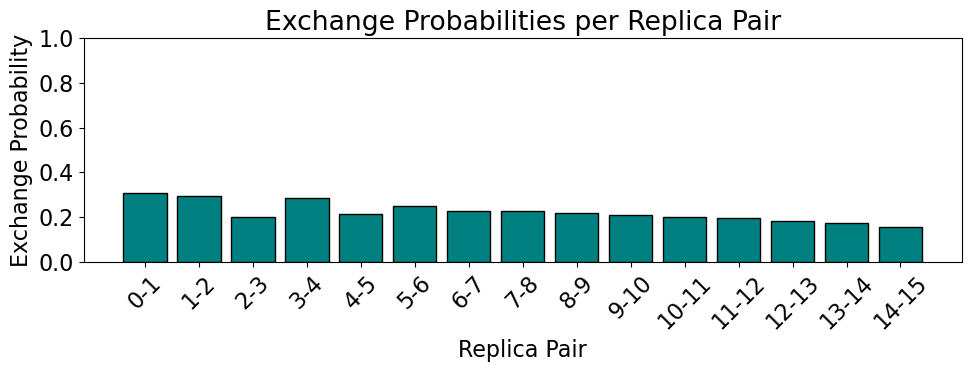

In [8]:
import matplotlib.pyplot as plt

# Plot exchange probabilities as a histogram
plt.figure(figsize=(10, 4))
x = list(range(len(exchange_probs)))
plt.bar(x, exchange_probs, color='teal', edgecolor='black')

plt.xticks(x, [f'{i}-{i+1}' for i in x], rotation=45)
plt.xlabel('Replica Pair')
plt.ylabel('Exchange Probability')
plt.title('Exchange Probabilities per Replica Pair')
plt.ylim(0, 1.0)

plt.tight_layout()
plt.show()
